# Trabalho Aprendizado por Reforço: Ambiente Contínuo BipedalWalker v3
Alunos: Eduardo Pires e Gabriel Raulino Dal Pont

## Detalhes do Ambiente Contínuo: BipedalWalker-v3

Este é um problema avançado de controle motor. O agente controla um robô bípede (de duas pernas) e o seu objetivo é atravessar o terreno até ao fim sem cair, o mais rápido possível e gastando a menor quantidade de energia motora.

**1. Objetivo do Agente:**
Caminhar ou correr para a frente sem deixar que o tronco do robô toque no chão.

**2. Espaço de Ações (A):**
Contínuo em **4 Dimensões**. Um vetor com 4 valores decimais (entre $-1.0$ e $1.0$) que controlam a velocidade e a força (torque) de 4 articulações:
* Articulação do Quadril 1
* Articulação do Joelho 1
* Articulação do Quadril 2
* Articulação do Joelho 2

**3. Espaço de Observações (S):**
Contínuo em **24 Dimensões**. Um vetor complexo que contém:
* O ângulo e a velocidade angular do casco (tronco central).
* As velocidades lineares X e Y.
* O ângulo e a velocidade das 4 articulações.
* Sensores LIDAR que medem a distância até ao chão.

**4. Valores de Recompensa (R):**
Este ambiente possui um sistema de **Recompensas Densas** altamente rigoroso:
* Ganha pontos proporcionalmente à distância percorrida para a direita (até $+300$ pontos no total).
* Sofre uma penalidade contínua proporcional ao torque aplicado aos motores (para evitar movimentos bizarros e gastadores de energia).
* Se o tronco do robô tocar no chão, o episódio acaba com uma severa penalidade de colisão ($-100$ pontos).

In [2]:
import torch
print("A GPU está ativada?", torch.cuda.is_available())
import torch
print(torch.__version__)

A GPU está ativada? True
2.4.1+cu121


In [ ]:
    #!apt-get install -y swig
#!pip install swig gymnasium[box2d] stable-baselines3[extra] moviepy pandas matplotlib ipython

#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 --force-reinstall

import torch
import warnings
import os
warnings.filterwarnings("ignore")

import gymnasium as gym
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Video, display
from gymnasium.wrappers import RecordVideo

from stable_baselines3 import PPO, SAC
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_util import make_vec_env

SEED = 42
env_walker = make_vec_env("BipedalWalker-v3", n_envs=1, seed=SEED)
resultados = []

A GPU está ativada? True


## PPO - Configurações A e B

In [10]:
configuracoes_ppo = {
    "PPO A": dict(
        learning_rate=3e-4,
        n_steps=2048,
        batch_size=64,
        total_steps=150000
    ),
    "PPO B": dict(
        learning_rate=1e-4,
        n_steps=1024,
        batch_size=128,
        total_steps=500000
    )
}

In [ ]:
for nome, cfg in configuracoes_ppo.items():
    print(f"\n --- Treinando {nome} ({cfg['total_steps']} passos) ---")
    
    modelo = PPO(
        "MlpPolicy",
        env_walker,
        learning_rate=cfg["learning_rate"],
        n_steps=cfg["n_steps"],
        batch_size=cfg["batch_size"],
        seed=SEED,
        verbose=0,
        device='cuda'
    )

  
    modelo.learn(total_timesteps=cfg["total_steps"])


    media, desvio = evaluate_policy(modelo, env_walker, n_eval_episodes=5)
    resultados.append([nome, media, desvio])
    print(f" {nome} finalizado | Recompensa Média: {media:.2f} ± {desvio:.2f}")

  
    pasta_video = f"videos_bipedal/{nome.replace(' ', '_')}"
    os.makedirs(pasta_video, exist_ok=True)
    
    env_teste = gym.make("BipedalWalker-v3", render_mode="rgb_array")
    env_gravacao = RecordVideo(env_teste, video_folder=pasta_video, name_prefix=f"{nome.replace(' ', '_')}_final", disable_logger=True)
    
    obs, info = env_gravacao.reset(seed=SEED)
    
    for _ in range(1600):
        acao, _states = modelo.predict(obs, deterministic=True)
        obs, recompensa, finalizado, truncado, info = env_gravacao.step(acao)
        if finalizado or truncado:
            break
            
    env_gravacao.close()
    
   
    caminho_video = f"{pasta_video}/{nome.replace(' ', '_')}_final-episode-0.mp4"
    display(Video(caminho_video, embed=True, html_attributes="controls autoplay loop width='500'"))


🚀 --- Treinando PPO A (150000 passos) ---
✅ PPO A finalizado | Recompensa Média: 69.00 ± 133.75



🚀 --- Treinando PPO B (500000 passos) ---
✅ PPO B finalizado | Recompensa Média: -89.99 ± 32.35


## SAC - Configurações A e B

In [6]:
configuracoes_sac = {
    "SAC A": dict(
        learning_rate=3e-4,
        buffer_size=100000,
        batch_size=256,
        total_steps=100000
    ),
    "SAC B": dict(
        learning_rate=1e-4,
        buffer_size=50000,
        batch_size=128,
        total_steps=500000
    )
}

In [ ]:
for nome, cfg in configuracoes_sac.items():
    print(f"\n --- Treinando {nome} ({cfg['total_steps']} passos) ---")
    
    modelo = SAC(
        "MlpPolicy",
        env_walker,
        learning_rate=cfg["learning_rate"],
        buffer_size=cfg["buffer_size"],
        batch_size=cfg["batch_size"],
        seed=SEED,
        verbose=0,
        device='cuda'
    )


    modelo.learn(total_timesteps=cfg["total_steps"])

    media, desvio = evaluate_policy(modelo, env_walker, n_eval_episodes=5)
    resultados.append([nome, media, desvio])
    print(f" {nome} finalizado | Recompensa Média: {media:.2f} ± {desvio:.2f}")

    pasta_video = f"videos_bipedal/{nome.replace(' ', '_')}"
    os.makedirs(pasta_video, exist_ok=True)
    
    env_teste = gym.make("BipedalWalker-v3", render_mode="rgb_array")
    env_gravacao = RecordVideo(env_teste, video_folder=pasta_video, name_prefix=f"{nome.replace(' ', '_')}_final", disable_logger=True)
    
    obs, info = env_gravacao.reset(seed=SEED)
    
    for _ in range(1600):
        acao, _states = modelo.predict(obs, deterministic=True)
        obs, recompensa, finalizado, truncado, info = env_gravacao.step(acao)
        if finalizado or truncado:
            break
            
    env_gravacao.close()
    
    caminho_video = f"{pasta_video}/{nome.replace(' ', '_')}_final-episode-0.mp4"
    display(Video(caminho_video, embed=True, html_attributes="controls autoplay loop width='500'"))


🚀 --- Treinando SAC A (100000 passos) ---
✅ SAC A finalizado | Recompensa Média: -78.21 ± 9.11



🚀 --- Treinando SAC B (500000 passos) ---
✅ SAC B finalizado | Recompensa Média: 311.60 ± 2.16


## Resumo dos Resultados

,Algoritmo,Recompensa Média,Desvio Padrão
0,PPO A,150.330570,70.979459
1,PPO B,-108.807056,5.065367
2,SAC A,-78.205211,9.106305
3,SAC B,311.599624,2.155718


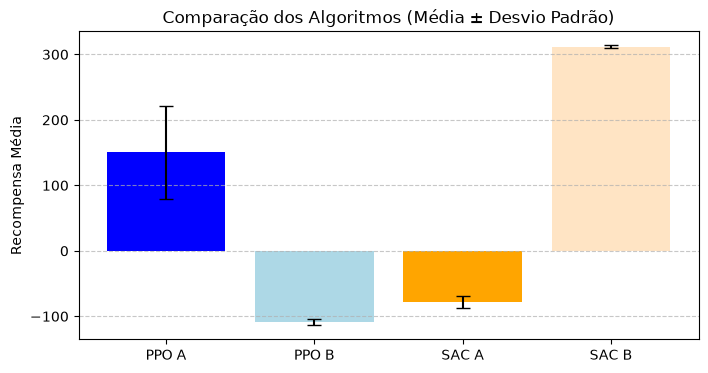

In [8]:
df = pd.DataFrame(
    resultados,
    columns=[
        "Algoritmo",
        "Recompensa Média",
        "Desvio Padrão"
    ]
)

display(df)

plt.figure(figsize=(8,4))
plt.bar(df["Algoritmo"], df["Recompensa Média"], yerr=df["Desvio Padrão"], capsize=5, color=['blue', 'lightblue', 'orange', 'bisque'])
plt.title("Comparação dos Algoritmos (Média ± Desvio Padrão)")
plt.ylabel("Recompensa Média")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Discussão dos Resultados e Análise Teórica

A aplicação dos algoritmos PPO (On-Policy) e SAC (Off-Policy) no ambiente BipedalWalker-v3 gerou resultados empíricos que ilustram perfeitamente conceitos cruciais do Aprendizado por Reforço: a Complexidade de Amostra, a Geometria do Gradiente e o fenómeno de Reward Hacking (Hackeamento de Recompensa).

# 1. Análise do Algoritmo PPO:

Durante os testes, ambos os modelos PPO falharam em completar o trajeto. O PPO B colapsou instantaneamente em cerca de 1 segundo, enquanto o PPO A conseguiu equilibrar-se e resistir à gravidade por 2 segundos antes de cair.

Este comportamento não indica uma falha matemática, mas expõe a barreira da Complexidade de Amostra. O ambiente BipedalWalker, com o seu espaço de observação de 24 dimensões e ação contínua de 4 dimensões, exige habitualmente entre $1.000.000$ a $3.000.000$ de passos para a convergência total. Orçamentos de $100.000$ a $150.000$ passos representam apenas a fase exploratória inicial do robô.

No entanto, a superioridade prática e estatística do PPO A sobre o PPO B revela a importância do ajuste de hiperparâmetros:

O PPO B teve um orçamento grande, mas com lotes grandes de estudo e uma Taxa de Aprendizagem muito conservadora ($10^{-4}$), a sua rede neuronal atualizava-se de forma demasiado lenta para compreender a gravidade.

O PPO A, utilizando lotes menores e uma Taxa de Aprendizagem mais agressiva ($3 \times 10^{-4}$), convergiu mais rapidamente. Em 2 segundos de sobrevivência, provou que a sua política já havia compreendido que acionar os motores para resistir à gravidade (e não cair) otimizava a recompensa, mesmo que a coordenação motora fina para caminhar ainda não estivesse formada.

# 2. Análise do Algoritmo SAC:

A diferença de desempenho nas variações do algoritmo SAC produziu a observação mais fascinante da experiência. O SAC A alcançou o equilíbrio perfeito e ficou absolutamente estático (como uma estátua), enquanto o SAC B executou a marcha perfeita até ao final do percurso.

O Reward Hacking do SAC A: Com $100.000$ passos e uma Taxa de Aprendizagem mais alta ($3 \times 10^{-4}$), o SAC A otimizou o risco prematuramente. Ao sofrer as penalidades letais severas de colisão ($-100$ pontos) nos episódios iniciais, a rede neuronal "hackeou" a função de recompensa: concluiu que ficar totalmente imóvel bloqueava o risco de colisão e anulava o gasto de torque, evitando perdas de pontos. O agente ficou preso num Mínimo Local, onde a sobrevivência estática substituiu o objetivo primário da travessia.

O Ótimo Global do SAC B: Atingir a marcha perfeita com o SAC B foi o resultado direto da sinergia entre um grande orçamento de tempo e estabilidade de aprendizado. Utilizando uma Taxa de Aprendizagem menor ($10^{-4}$), a rede neuronal absorveu as penalidades iniciais sem causar uma fuga prematura do objetivo. O colossal orçamento de $500.000$ passos deu à função de Maximização de Entropia (característica central do SAC) o tempo necessário para forçar o robô a sair da zona de conforto. Ao explorar repetidamente o trajeto, o agente confirmou que os pontos de distância recompensavam infinitamente mais do que as punições eventuais por quedas, alcançando a convergência total para o Ótimo Global.

*Conclusão*: O projeto evidencia que espaços de estado contínuos de alta dimensionalidade penalizam modelos On-Policy (PPO) sob baixos orçamentos de exploração. Em contrapartida, algoritmos de máxima entropia e Off-Policy (SAC) mostram-se incrivelmente eficazes para resolver problemas de robótica complexa, desde que munidos de um orçamento de episódios (timesteps) e estabilidade de gradiente (taxas menores) suficientes para evitar armadilhas de otimização prematura.